# Exploratory Data Analysis (EDA)

## Objective

The purpose of this notebook is to explore the dataset and identify patterns, relationships, and variables that may be important for predicting the winner of a League of Legends match after the 10-minute mark.

The analysis focuses on observations where `frame = 10`, as the project's area of research focuses on making a prediction as early on in the match as possible.

# 1. Importing Libraries

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

# 2. Read Data

In [18]:
df = pd.read_csv("../data/raw/lol_ranked_games.csv")

# 3. Create 10-minute Dataset

In [19]:
df10 = df[df["frame"] == 10].copy()
print(df10.shape)

(24912, 59)


# 4. Understanding Variables

In [20]:
continuous_features = [
    "goldDiff",
    "expDiff",
    "champLevelDiff",
    "kills",
    "deaths",
    "assists"
]

In [21]:
df10[continuous_features].describe()

,goldDiff,expDiff,champLevelDiff,kills,deaths,assists
count,24912.000000,24912.000000,24912.000000,24912.000000,24912.000000,24912.000000
mean,38.865406,-25.643626,-0.006350,5.858060,5.770191,5.787091
std,2392.274190,1885.239239,0.471679,2.903241,2.889751,3.778643
min,-12403.000000,-12297.000000,-3.800000,0.000000,0.000000,0.000000
25%,-1483.000000,-1223.000000,-0.200000,4.000000,4.000000,3.000000
50%,40.000000,-18.000000,0.000000,6.000000,5.000000,5.000000
75%,1565.000000,1163.000000,0.200000,8.000000,8.000000,8.000000
max,12535.000000,10331.000000,3.400000,32.000000,21.000000,48.000000


## 5. Histogram of Gold Difference after 10 minutes

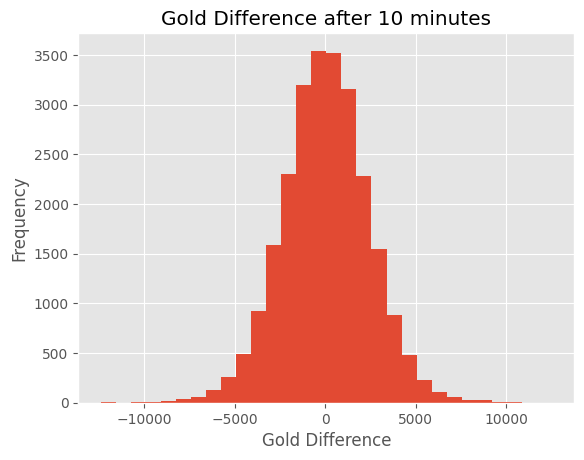

In [22]:
df10["goldDiff"].hist(bins=30)

plt.title("Gold Difference after 10 minutes")
plt.xlabel("Gold Difference")
plt.ylabel("Frequency")

plt.show()

## 6. Relationship between features and match outcome

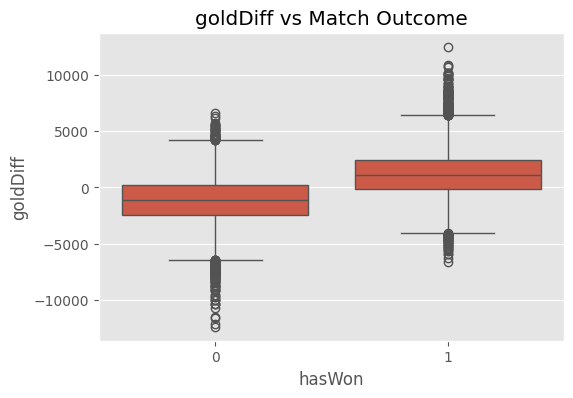

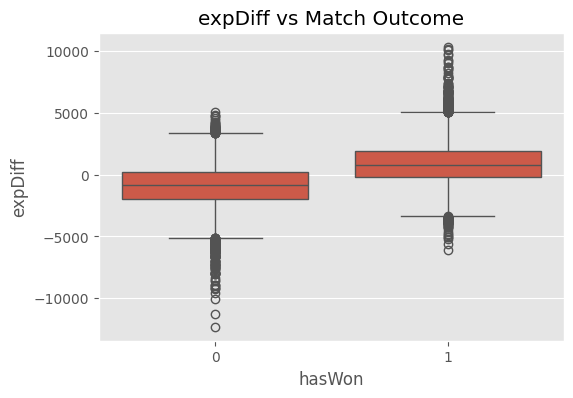

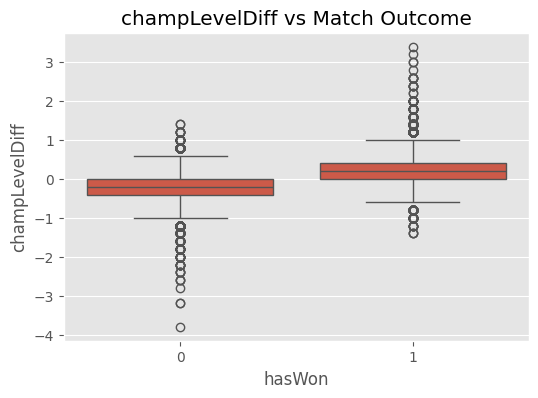

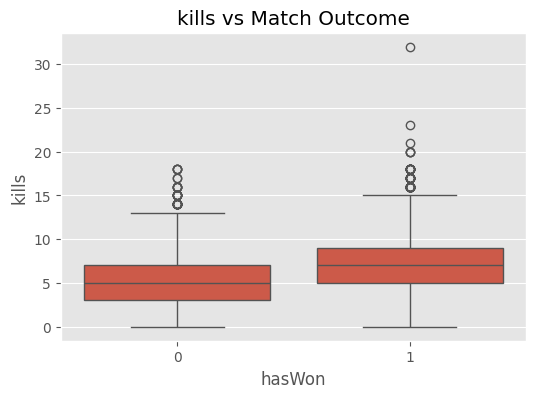

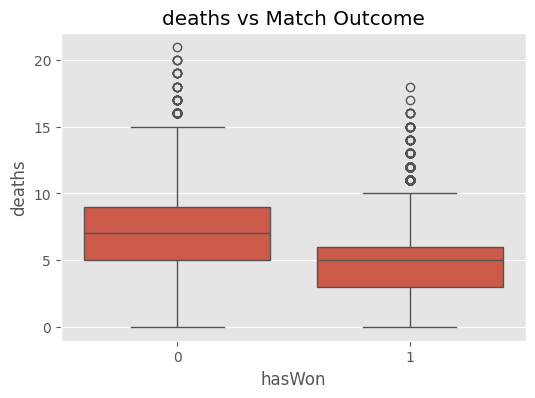

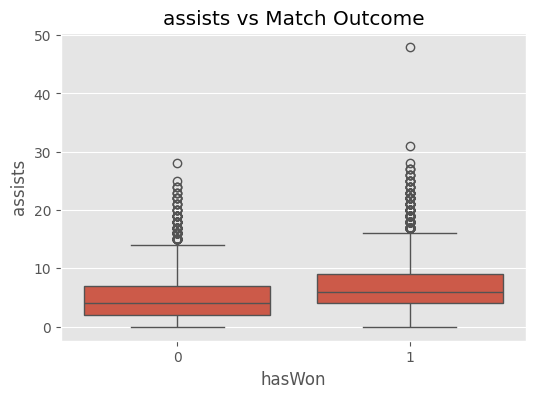

In [23]:
for feature in continuous_features:
    plt.figure(figsize=(6,4))

    sns.boxplot(
        data=df10,
        x="hasWon",
        y=feature
    )

    plt.title(f"{feature} vs Match Outcome")
    plt.show()

## 7. Objectives

In [24]:
objective_features = [
    "isFirstBlood",
    "isFirstTower",
    "killedFireDrake",
    "killedWaterDrake",
    "killedEarthDrake",
    "killedAirDrake",
    "killedRiftHerald"
]

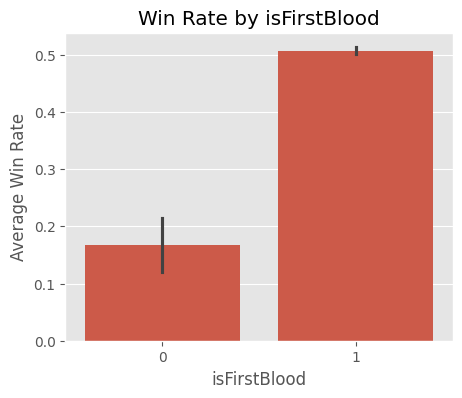

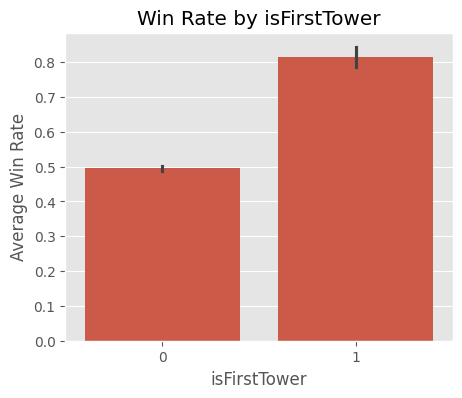

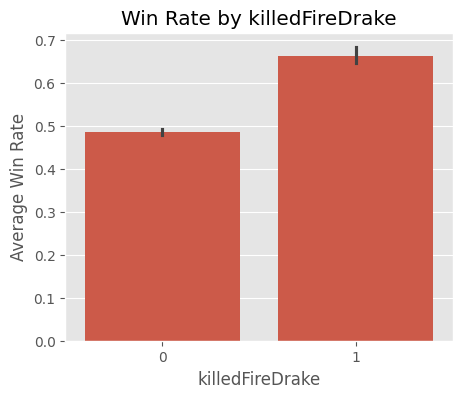

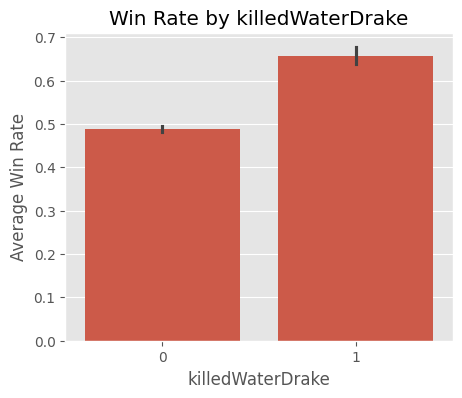

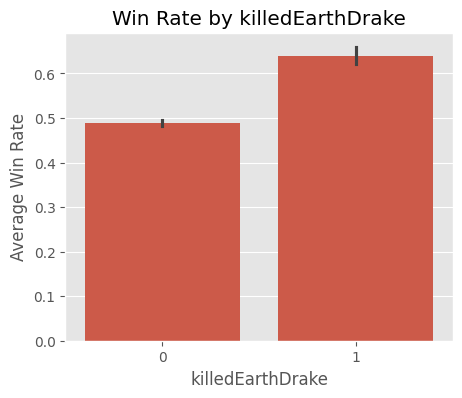

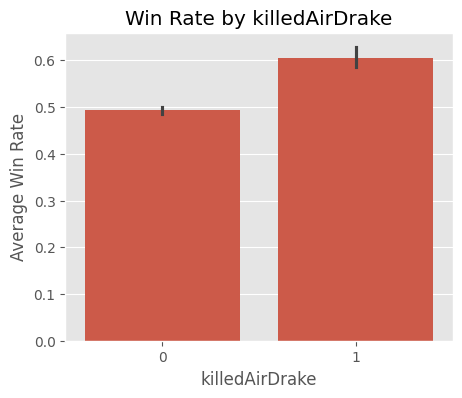

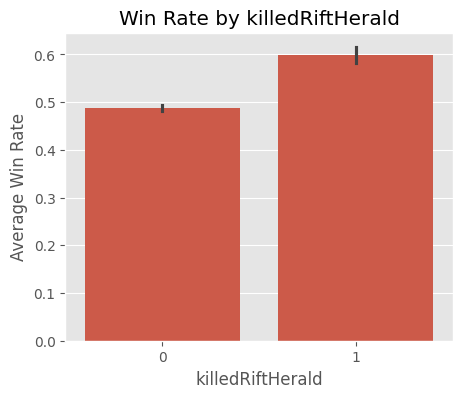

In [25]:
for feature in objective_features:

    plt.figure(figsize=(5,4))

    sns.barplot(
        data=df10,
        x=feature,
        y="hasWon"
    )

    plt.title(f"Win Rate by {feature}")

    plt.ylabel("Average Win Rate")

    plt.show()

## 8. Correlation analysis

In [26]:
correlations = (
    df10.corr(numeric_only=True)["hasWon"]
    .sort_values(ascending=False)
)

correlations

hasWon                     1.000000
goldDiff                   0.495013
expDiff                    0.472913
champLevelDiff             0.432210
kills                      0.320116
assists                    0.250563
killedFireDrake            0.107970
isFirstTower               0.099823
killedWaterDrake           0.098230
killedEarthDrake           0.088699
killedRiftHerald           0.075466
killedAirDrake             0.066077
isFirstBlood               0.065287
destroyedBotOuterTurret    0.060639
destroyedTopOuterTurret    0.059177
destroyedMidOuterTurret    0.058821
destroyedBotInnerTurret    0.046726
wardsDestroyed             0.038880
destroyedBotNexusTurret    0.037260
destroyedBotBaseTurret     0.033667
destroyedBotInhibitor      0.030847
destroyedMidInnerTurret    0.021807
destroyedTopInnerTurret    0.021627
destroyedMidNexusTurret    0.016654
destroyedTopNexusTurret    0.015418
wardsPlaced                0.014138
destroyedMidInhibitor      0.012588
destroyedTopInhibitor      0

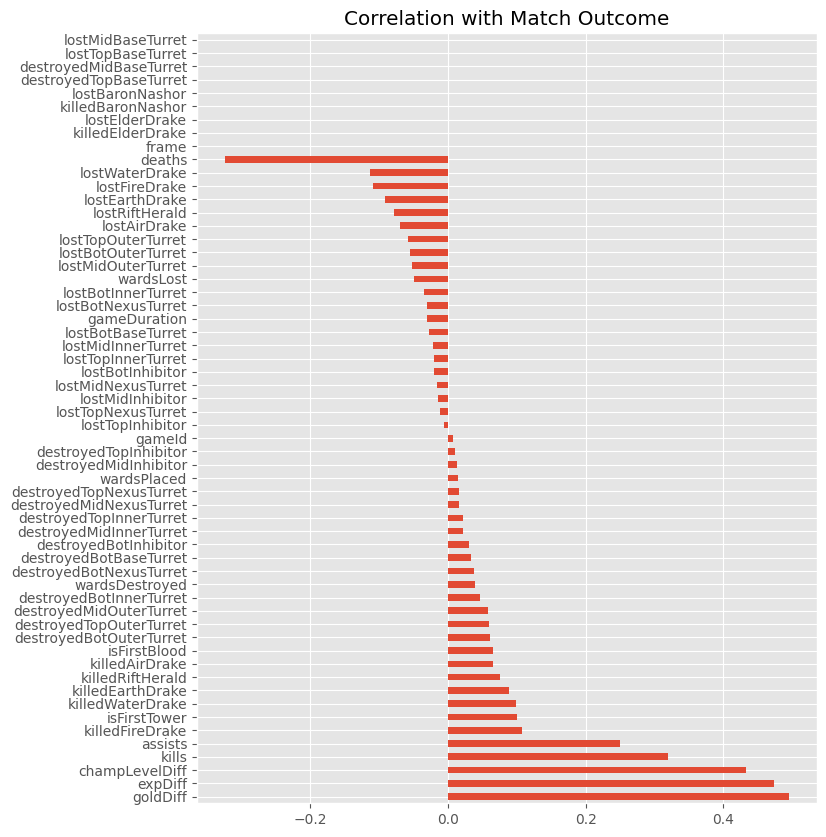

In [27]:
plt.figure(figsize=(8,10))

correlations.drop("hasWon").plot(kind="barh")

plt.title("Correlation with Match Outcome")

plt.show()

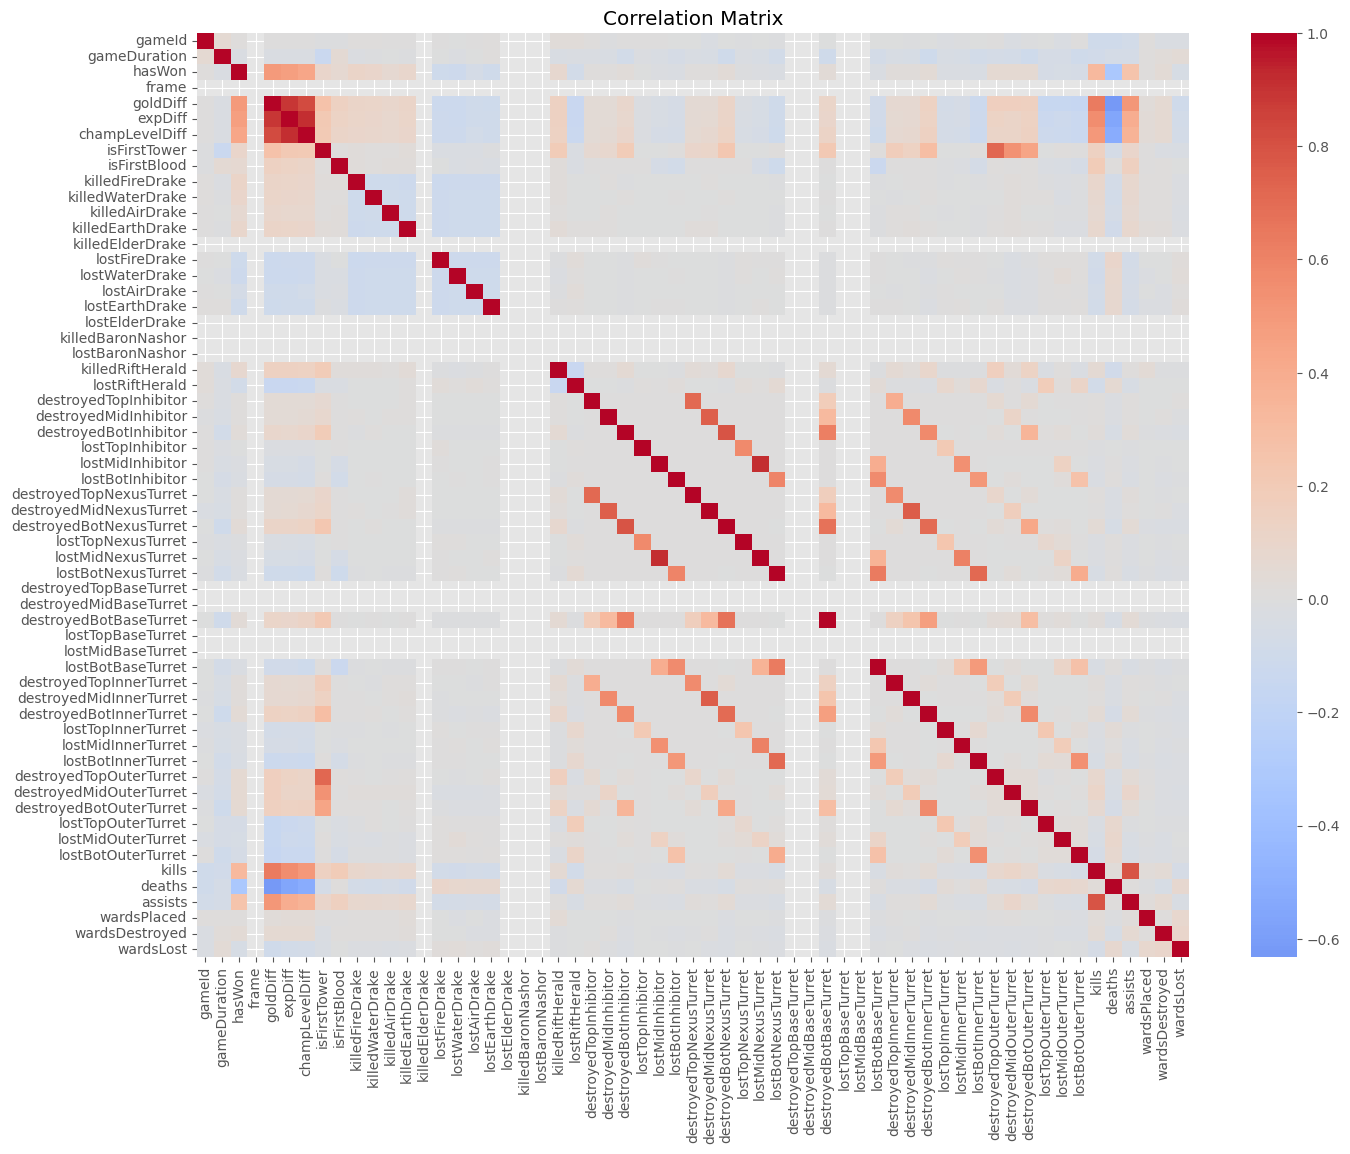

In [28]:
plt.figure(figsize=(16,12))

sns.heatmap(
    df10.corr(numeric_only=True),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")

plt.show()

## Summary

The exploratory analysis shows that several variables already differ noticeably after 10 minutes.

The strongest indicators seem to be:

- Gold Difference
- Experience Difference
- Champion Level Difference
- Kills
- Objectives such as First Tower

These variables will be used in the machine learning models.